# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 2
- **Date:** 22/07/2026

---

In [5]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-02"

print("Notebook Loaded Successfully")

Notebook Loaded Successfully


In [6]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)

Notebook Fingerprint:
3f1828dbdaec4dbb4fea742003ba5e6aafc1605e09094f6e45572a91433cc5ad


# Experiment Details

## Objective

To study and implement **Simple Logistic Regression (SiLR)** and **Multiple Logistic Regression (MuLR)**
using the *Default of Credit Card Clients* dataset (UCI ML Repository, ID: 350),
in order to predict whether a credit card client will **default on payment next month**
(binary target: 1 = default, 0 = no default), and to compare the classification
performance of both models using standard metrics (Accuracy, Precision, Recall, F1-Score, and ROC-AUC).

## Theory

**Classification** is a supervised machine learning task where the goal is to assign a discrete
class label to each input. **Logistic Regression** is the standard linear model for binary
classification — it estimates the *probability* that an observation belongs to class 1.

**1. Simple Logistic Regression (SiLR)** uses a single predictor $x$ to model the log-odds of
the positive class:

$$\log\frac{P(y=1)}{1-P(y=1)} = \beta_0 + \beta_1 x$$

which is equivalent to:

$$P(y=1) = \sigma(\beta_0 + \beta_1 x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$$

where $\sigma(\cdot)$ is the **sigmoid (logistic) function** that squashes any real value into $(0,1)$.

**2. Multiple Logistic Regression (MuLR)** extends this to $p$ predictors:

$$P(y=1) = \sigma\left(\beta_0 + \sum_{j=1}^{p} \beta_j x_j\right)$$

Parameters are estimated by **maximum likelihood estimation (MLE)** — maximising the log-likelihood
over the training set using iterative solvers (e.g. L-BFGS, Newton-CG).

**Decision boundary:** A predicted probability $\geq 0.5$ is classified as default (1); below 0.5 as
no default (0).

**Why this dataset?** Credit default prediction is a classic imbalanced classification problem
(~22% defaults). Using demographic attributes (age, education, marriage) alongside payment
history and bill/payment amounts provides a real-world context for understanding how linear
decision boundaries perform on tabular financial data.

**Regularisation (L2 / Ridge):** Logistic Regression in scikit-learn includes an L2 penalty
controlled by $C = 1/\lambda$. A smaller $C$ applies stronger regularisation, reducing overfitting
when features are collinear or the dataset is high-dimensional.

**Evaluation Metrics:**
- **Accuracy** — fraction of correct predictions: $\frac{TP+TN}{TP+TN+FP+FN}$
- **Precision** — of all predicted defaults, how many were actual: $\frac{TP}{TP+FP}$
- **Recall (Sensitivity)** — of all actual defaults, how many were caught: $\frac{TP}{TP+FN}$
- **F1-Score** — harmonic mean of Precision and Recall: $2 \cdot \frac{P \cdot R}{P+R}$
- **ROC-AUC** — area under the Receiver Operating Characteristic curve; 1.0 = perfect, 0.5 = random

## Dataset

- **Name:** Default of Credit Card Clients
- **Source:** UCI Machine Learning Repository (ID: 350)  
  — https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
- **Total Instances:** 30,000 credit card clients (Taiwan, April–September 2005)
- **Features (23):** LIMIT_BAL, SEX, EDUCATION, MARRIAGE, AGE, PAY_0–PAY_6, BILL_AMT1–6, PAY_AMT1–6
- **Target:** `default.payment.next.month` (1 = default, 0 = no default)
- **Class Distribution:** ~22% defaults (imbalanced)
- **Missing Values:** None
- **Task Type:** Binary Classification
- **Licence:** CC BY 4.0

In [7]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import io, os, zipfile
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")

All libraries imported successfully.


In [8]:
# Step 2 — Download and load the UCI dataset (ID: 350)

DATA_URL = ("https://archive.ics.uci.edu/static/public/350/"
            "default+of+credit+card+clients.zip")

DATA_DIR = "credit_default_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "dataset.zip")

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Download complete.")
else:
    print("Dataset archive already present.")

with zipfile.ZipFile(zip_path) as zf:
    print("Contents:", zf.namelist())
    zf.extractall(DATA_DIR)

# Locate the XLS/XLSX file
import glob
xls_files = glob.glob(os.path.join(DATA_DIR, "**", "*.xls*"), recursive=True)
print("Excel files found:", xls_files)

# Read — the file is .xls format (xlrd engine)
df_raw = pd.read_excel(xls_files[0], header=1, engine="xlrd")

# Rename target column for convenience
df_raw.rename(columns={"default payment next month": "default"}, inplace=True)
# Some versions have a dot-separated name — handle both
if "default.payment.next.month" in df_raw.columns:
    df_raw.rename(columns={"default.payment.next.month": "default"}, inplace=True)

print("\nDataset loaded successfully.")
print(df_raw.head())

Dataset archive already present.
Contents: ['default of credit card clients.xls']
Excel files found: ['credit_default_data\\default of credit card clients.xls']

Dataset loaded successfully.
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  PAY_6  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  \
0     -2     -2       3913       3102        689          0          0   
1      0      2       2682       1725       2682       3272       3455   
2      0      0      29239      14027      13559      14331      14948   
3      0      0      46990      48233 

In [9]:
# Step 3 — Dataset overview

print("Dataset : Default of Credit Card Clients")
print("Samples :", df_raw.shape[0])
print("Columns :", df_raw.shape[1])
print("Source  : UCI ML Repository (ID: 350)")
print("Target  : default (1 = default, 0 = no default)")

Dataset : Default of Credit Card Clients
Samples : 30000
Columns : 25
Source  : UCI ML Repository (ID: 350)
Target  : default (1 = default, 0 = no default)


In [10]:
# Step 4 — Explore dataset structure

print("Shape:", df_raw.shape)
print("\nColumn names:", df_raw.columns.tolist())
print("\nFirst 10 rows:")
print(df_raw.head(10))

Shape: (30000, 25)

Column names: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

First 10 rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   
5   6      50000    1          1         2   37      0      0      0      0   
6   7     500000    1          1         2   29      0      0      0      0   
7   8     100000    2          2         2  

In [11]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df_raw.info()
print("\nData Types:")
print(df_raw.dtypes)
print("\nUnique Values per Column:")
print(df_raw.nunique())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21

In [12]:
# Step 6 — Check for missing values

missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print("\nTotal missing values:", df_raw.isnull().sum().sum())

Missing values per column:
No missing values found.

Total missing values: 0


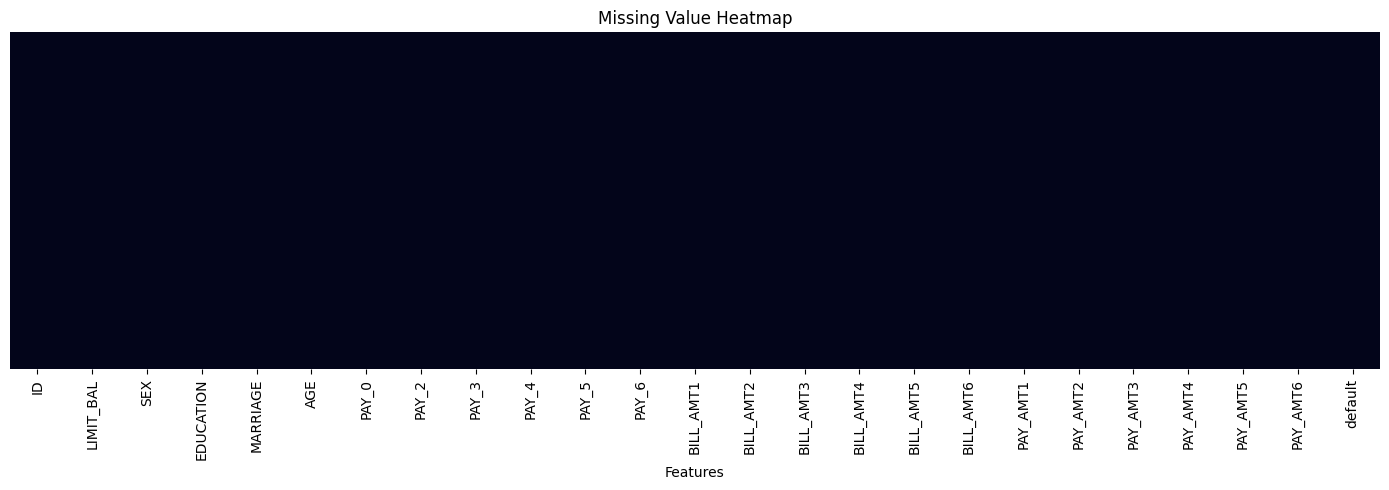

In [13]:
# Step 7 — Visualise missing values

plt.figure(figsize=(14, 5))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Value Heatmap")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

In [14]:
# Step 8 — Check and remove duplicate rows

dup_count = df_raw.duplicated().sum()
print("Duplicate rows:", dup_count)
df = df_raw.drop_duplicates().reset_index(drop=True)

# Drop the ID column if present
if "ID" in df.columns:
    df.drop(columns=["ID"], inplace=True)

print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Shape after cleaning: (30000, 24)


In [15]:
# Step 9 — Descriptive statistics

print(df.describe().T)

             count           mean            std       min       25%  \
LIMIT_BAL  30000.0  167484.322667  129747.661567   10000.0  50000.00   
SEX        30000.0       1.603733       0.489129       1.0      1.00   
EDUCATION  30000.0       1.853133       0.790349       0.0      1.00   
MARRIAGE   30000.0       1.551867       0.521970       0.0      1.00   
AGE        30000.0      35.485500       9.217904      21.0     28.00   
PAY_0      30000.0      -0.016700       1.123802      -2.0     -1.00   
PAY_2      30000.0      -0.133767       1.197186      -2.0     -1.00   
PAY_3      30000.0      -0.166200       1.196868      -2.0     -1.00   
PAY_4      30000.0      -0.220667       1.169139      -2.0     -1.00   
PAY_5      30000.0      -0.266200       1.133187      -2.0     -1.00   
PAY_6      30000.0      -0.291100       1.149988      -2.0     -1.00   
BILL_AMT1  30000.0   51223.330900   73635.860576 -165580.0   3558.75   
BILL_AMT2  30000.0   49179.075167   71173.768783  -69777.0   298

Class Distribution:
         Count  Percentage (%)
default                       
0        23364           77.88
1         6636           22.12


C:\Users\lab1\AppData\Local\Temp\ipykernel_17600\1895889666.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="default", data=df,


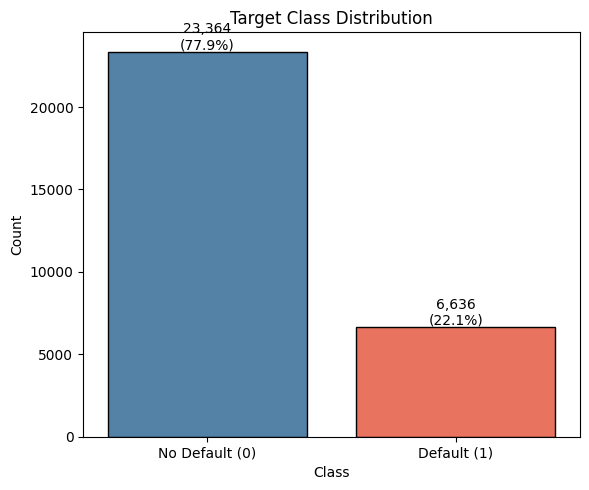

In [16]:
# Step 10 — Target class distribution

counts = df["default"].value_counts()
pct    = df["default"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(pd.DataFrame({"Count": counts, "Percentage (%)": pct.round(2)}))

plt.figure(figsize=(6, 5))
sns.countplot(x="default", data=df,
              palette=["steelblue", "tomato"], edgecolor="black")
plt.xticks([0, 1], ["No Default (0)", "Default (1)"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Class Distribution")
for i, v in enumerate(counts):
    plt.text(i, v + 150, f"{v:,}\n({pct.iloc[i]:.1f}%)", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

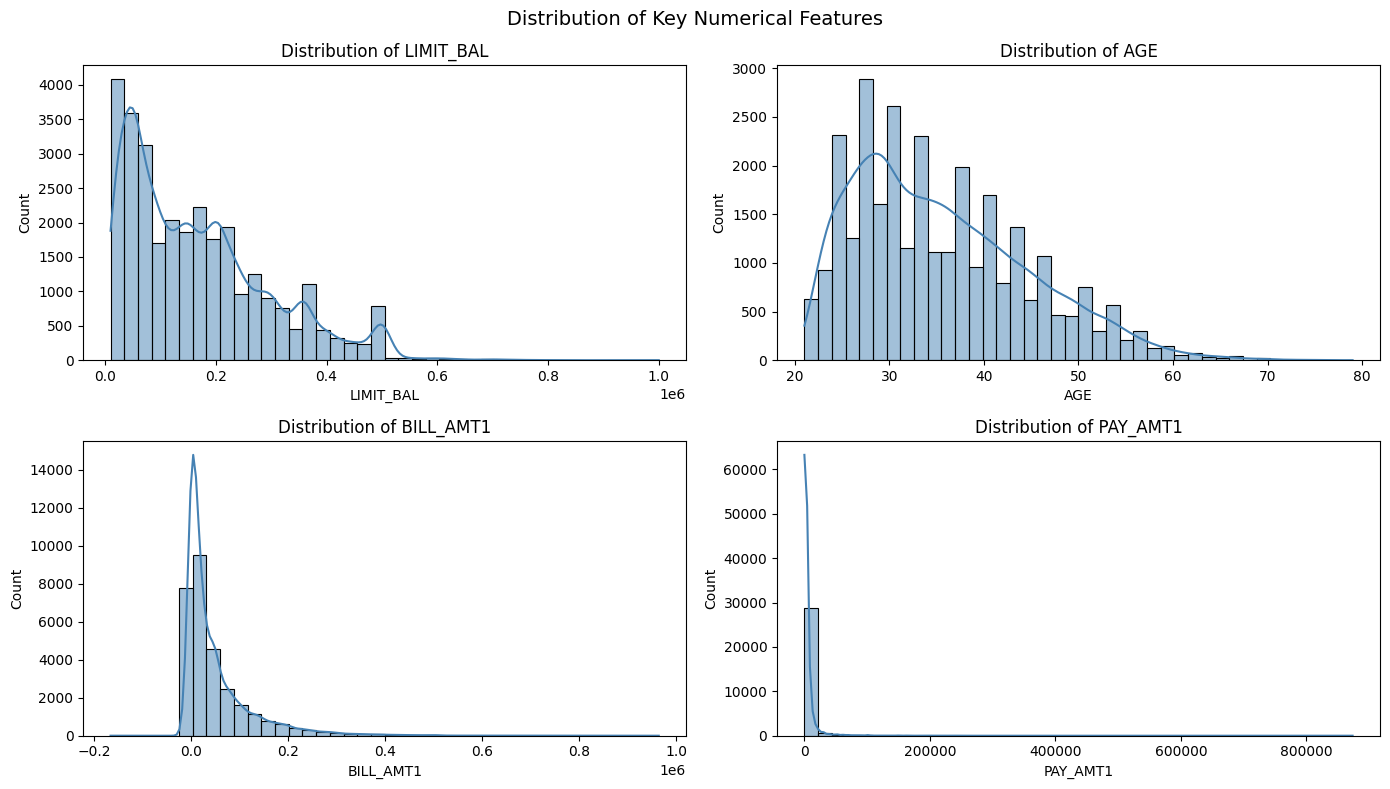

In [17]:
# Step 11 — Distribution of key numerical features

num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax,
                 color="steelblue", edgecolor="black")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

plt.suptitle("Distribution of Key Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\lab1\AppData\Local\Temp\ipykernel_17600\2052899352.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order,
C:\Users\lab1\AppData\Local\Temp\ipykernel_17600\2052899352.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order,
C:\Users\lab1\AppData\Local\Temp\ipykernel_17600\2052899352.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, order=order,


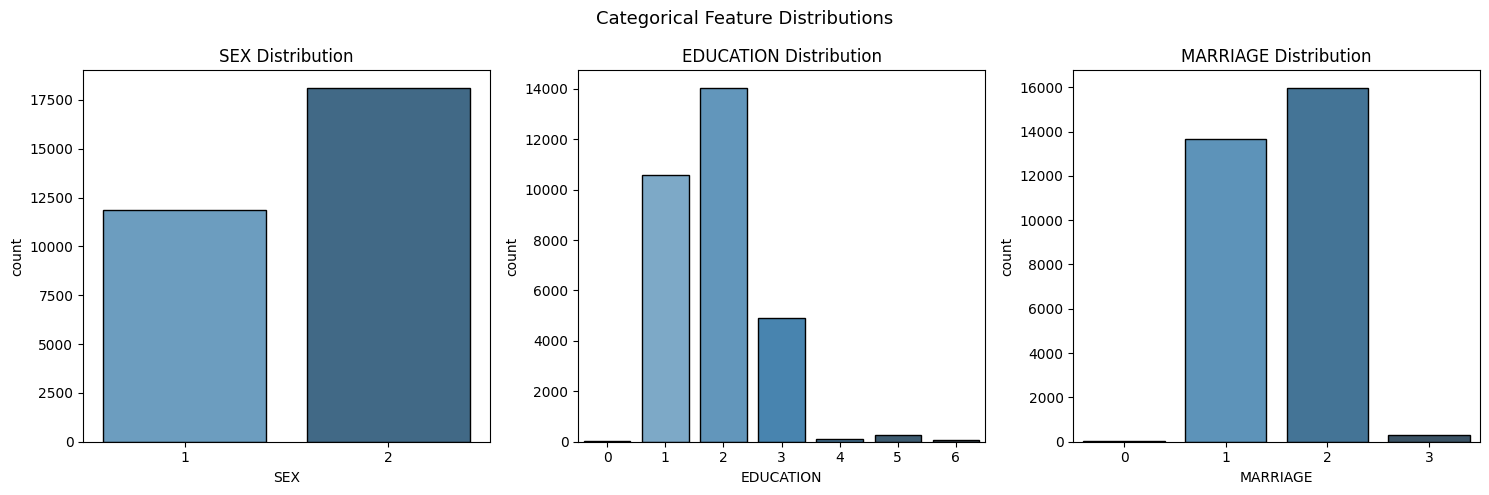

In [18]:
# Step 12 — Categorical feature distributions

cat_cols  = ["SEX", "EDUCATION", "MARRIAGE"]
cat_label = {
    "SEX":       {1: "Male", 2: "Female"},
    "EDUCATION": {1: "Grad School", 2: "University", 3: "High School",
                  4: "Others", 5: "Unknown", 6: "Unknown"},
    "MARRIAGE":  {0: "Others", 1: "Married", 2: "Single", 3: "Others"}
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, cat_cols):
    order = sorted(df[col].unique())
    sns.countplot(x=col, data=df, order=order,
                  palette="Blues_d", edgecolor="black", ax=ax)
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
plt.suptitle("Categorical Feature Distributions", fontsize=13)
plt.tight_layout()
plt.show()

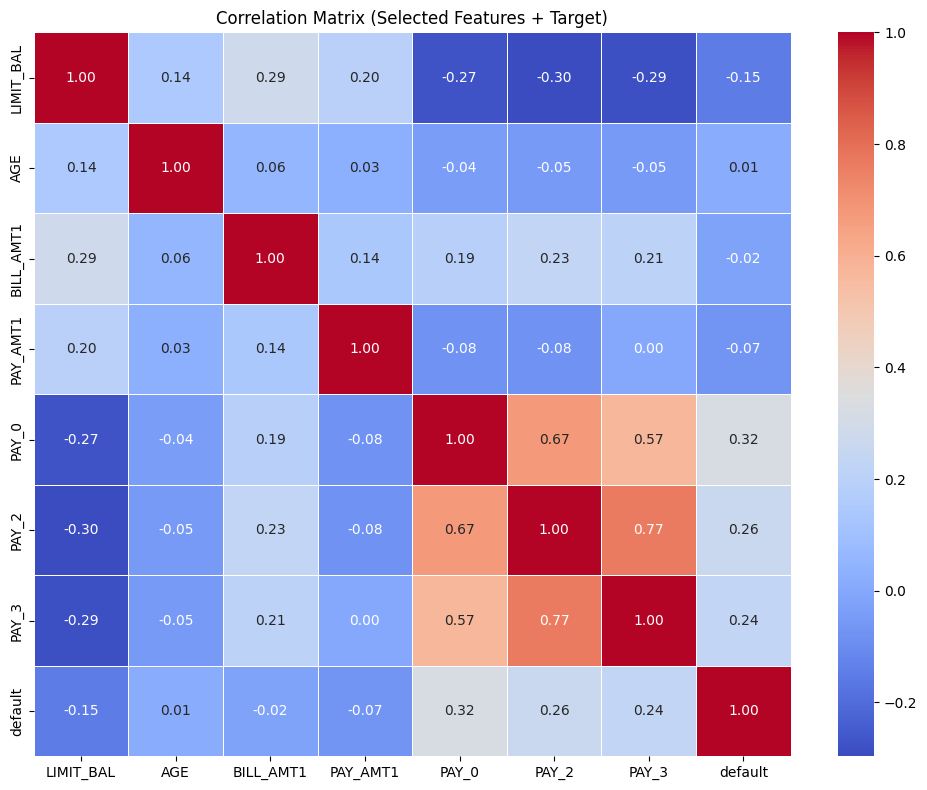

In [19]:
# Step 13 — Correlation matrix (numerical features)

corr_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1",
             "PAY_0", "PAY_2", "PAY_3", "default"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix (Selected Features + Target)")
plt.tight_layout()
plt.show()

---
# Implementation

## Part A — Simple Logistic Regression (SiLR)

Use only the **most correlated single feature** (`PAY_0` — repayment status in September 2005)
to predict the default class. This mirrors SLR from Lab 1 but with a logistic link function.


In [20]:
# Step 14 — Train Simple Logistic Regression (single feature: PAY_0)

X_simple = df[["PAY_0"]]
y        = df["default"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.20, random_state=42, stratify=y
)

scaler_s       = StandardScaler()
X_train_s_sc   = scaler_s.fit_transform(X_train_s)
X_test_s_sc    = scaler_s.transform(X_test_s)

slr_model = LogisticRegression(max_iter=500, random_state=42)
slr_model.fit(X_train_s_sc, y_train_s)

y_pred_s      = slr_model.predict(X_test_s_sc)
y_prob_s      = slr_model.predict_proba(X_test_s_sc)[:, 1]

acc_s   = accuracy_score(y_test_s, y_pred_s)
prec_s  = precision_score(y_test_s, y_pred_s)
rec_s   = recall_score(y_test_s, y_pred_s)
f1_s    = f1_score(y_test_s, y_pred_s)
auc_s   = roc_auc_score(y_test_s, y_prob_s)

print("=== SIMPLE LOGISTIC REGRESSION RESULTS (PAY_0 only) ===")
print(f"Equation : log-odds = {slr_model.intercept_[0]:.4f} + {slr_model.coef_[0][0]:.4f} * PAY_0 (scaled)")
print(f"Accuracy  : {acc_s:.4f}")
print(f"Precision : {prec_s:.4f}")
print(f"Recall    : {rec_s:.4f}")
print(f"F1-Score  : {f1_s:.4f}")
print(f"ROC-AUC   : {auc_s:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s, target_names=["No Default", "Default"]))

=== SIMPLE LOGISTIC REGRESSION RESULTS (PAY_0 only) ===
Equation : log-odds = -1.4182 + 0.8402 * PAY_0 (scaled)
Accuracy  : 0.8192
Precision : 0.6903
Recall    : 0.3308
F1-Score  : 0.4473
ROC-AUC   : 0.6762

Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.96      0.89      4673
     Default       0.69      0.33      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



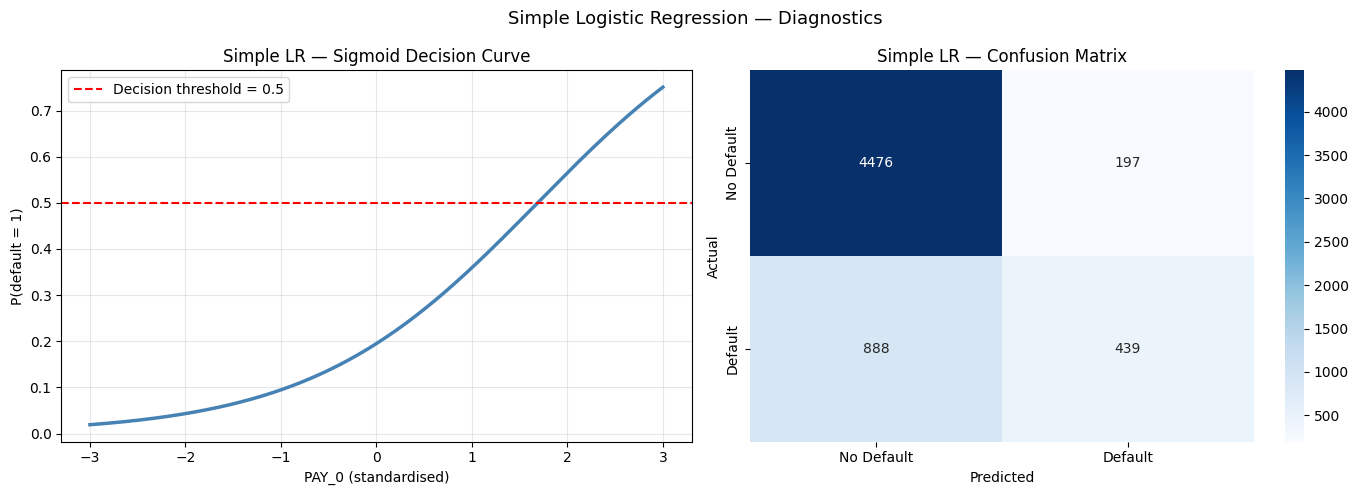

In [21]:
# Step 15 — Sigmoid decision curve and Confusion Matrix (SiLR)

# Sigmoid curve
x_range  = np.linspace(-3, 3, 300).reshape(-1, 1)
prob_curve = slr_model.predict_proba(x_range)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sigmoid
axes[0].plot(x_range, prob_curve, color="steelblue", linewidth=2.5)
axes[0].axhline(0.5, color="red", linestyle="--", label="Decision threshold = 0.5")
axes[0].set_xlabel("PAY_0 (standardised)")
axes[0].set_ylabel("P(default = 1)")
axes[0].set_title("Simple LR — Sigmoid Decision Curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Confusion Matrix
cm_s = confusion_matrix(y_test_s, y_pred_s)
sns.heatmap(cm_s, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].set_title("Simple LR — Confusion Matrix")

plt.suptitle("Simple Logistic Regression — Diagnostics", fontsize=13)
plt.tight_layout()
plt.show()

## Part B — Multiple Logistic Regression (MuLR)

Use **all 23 available features** (demographic + payment history + bill and payment amounts)
with L2 regularisation to predict credit card default. Feature scaling is applied
before model fitting, as Logistic Regression is sensitive to the magnitude of inputs.


In [22]:
# Step 16 — Feature engineering and preprocessing

# All features except target
feature_cols = [c for c in df.columns if c != "default"]

X_all = df[feature_cols]
y_all = df["default"]

print("Features used for MuLR:")
print(feature_cols)
print(f"\nTotal features: {len(feature_cols)}")
print(f"Class balance — No Default: {(y_all==0).sum()}  |  Default: {(y_all==1).sum()}")

Features used for MuLR:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Total features: 23
Class balance — No Default: 23364  |  Default: 6636


In [23]:
# Step 17 — Train Multiple Logistic Regression model

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)

mlr_model = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42)
mlr_model.fit(X_train_sc, y_train)

y_pred_m  = mlr_model.predict(X_test_sc)
y_prob_m  = mlr_model.predict_proba(X_test_sc)[:, 1]

acc_m   = accuracy_score(y_test, y_pred_m)
prec_m  = precision_score(y_test, y_pred_m)
rec_m   = recall_score(y_test, y_pred_m)
f1_m    = f1_score(y_test, y_pred_m)
auc_m   = roc_auc_score(y_test, y_prob_m)

print("=== MULTIPLE LOGISTIC REGRESSION RESULTS (all 23 features) ===")
print(f"Accuracy  : {acc_m:.4f}")
print(f"Precision : {prec_m:.4f}")
print(f"Recall    : {rec_m:.4f}")
print(f"F1-Score  : {f1_m:.4f}")
print(f"ROC-AUC   : {auc_m:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_m, target_names=["No Default", "Default"]))

=== MULTIPLE LOGISTIC REGRESSION RESULTS (all 23 features) ===
Accuracy  : 0.8077
Precision : 0.6868
Recall    : 0.2396
F1-Score  : 0.3553
ROC-AUC   : 0.7076

Classification Report:
              precision    recall  f1-score   support

  No Default       0.82      0.97      0.89      4673
     Default       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



Top 10 most influential features (by |coefficient|):
  Feature  Coefficient
    PAY_0     0.660990
BILL_AMT1    -0.316203
 PAY_AMT1    -0.202172
 PAY_AMT2    -0.179648
LIMIT_BAL    -0.133241
EDUCATION    -0.097310
    PAY_3     0.097205
    PAY_2     0.093100
BILL_AMT2     0.092931
      AGE     0.073843


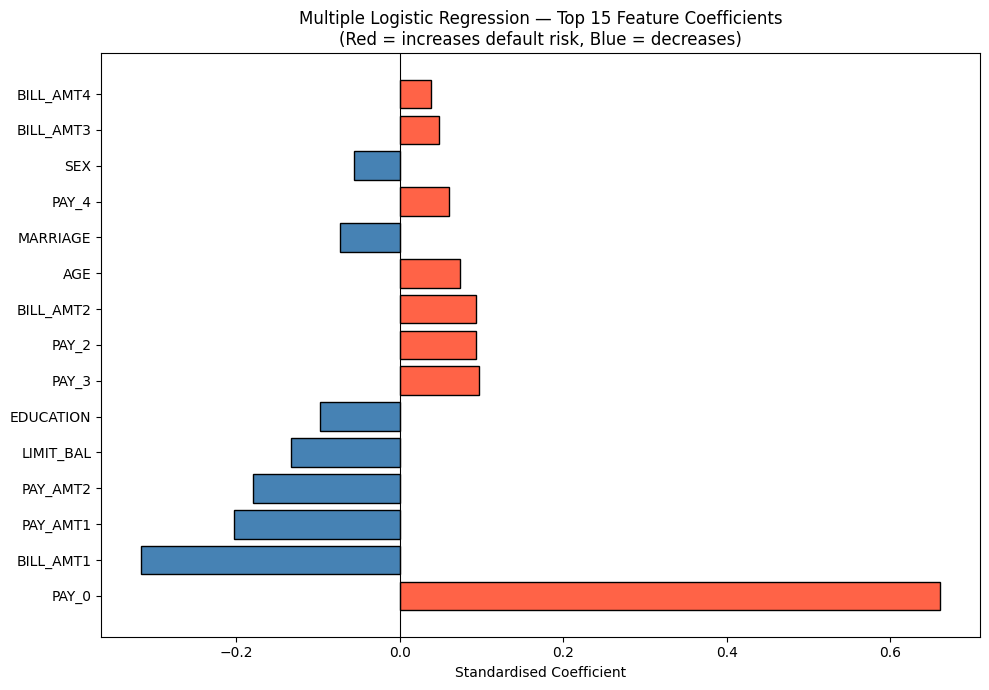

In [24]:
# Step 18 — Model coefficients (feature importance)

coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": mlr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=False)

print("Top 10 most influential features (by |coefficient|):")
print(coef_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 7))
top_coef = coef_df.head(15)
colors = ["tomato" if c > 0 else "steelblue" for c in top_coef["Coefficient"]]
plt.barh(top_coef["Feature"], top_coef["Coefficient"],
         color=colors, edgecolor="black")
plt.xlabel("Standardised Coefficient")
plt.title("Multiple Logistic Regression — Top 15 Feature Coefficients\n(Red = increases default risk, Blue = decreases)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

---
# Results


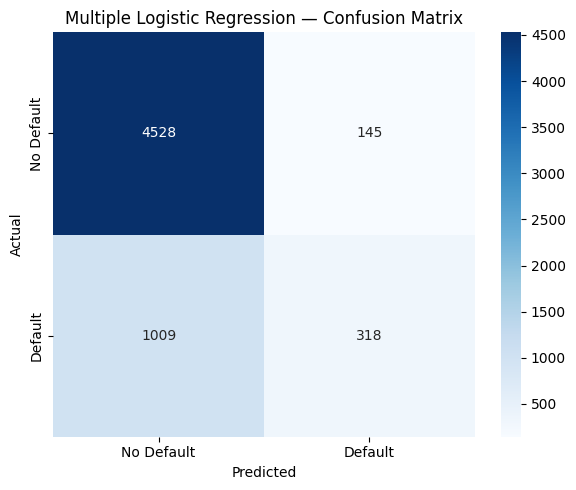

True Positives  (TP): 318
True Negatives  (TN): 4528
False Positives (FP): 145  (predicted default, actually not)
False Negatives (FN): 1009  (missed defaults — most costly in finance)


In [25]:
# Step 19 — Confusion Matrix (MuLR)

cm_m = confusion_matrix(y_test, y_pred_m)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_m, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multiple Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_m.ravel()
print(f"True Positives  (TP): {tp}")
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}  (predicted default, actually not)")
print(f"False Negatives (FN): {fn}  (missed defaults — most costly in finance)")

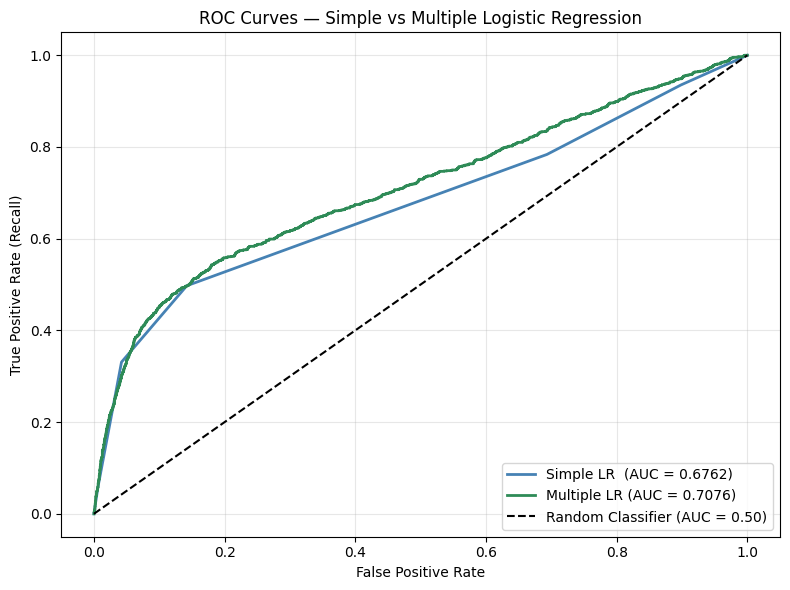

In [26]:
# Step 20 — ROC Curves: SiLR vs MuLR

fpr_s, tpr_s, _ = roc_curve(y_test_s, y_prob_s)
fpr_m, tpr_m, _ = roc_curve(y_test,   y_prob_m)

plt.figure(figsize=(8, 6))
plt.plot(fpr_s, tpr_s, color="steelblue", linewidth=2,
         label=f"Simple LR  (AUC = {auc_s:.4f})")
plt.plot(fpr_m, tpr_m, color="seagreen",  linewidth=2,
         label=f"Multiple LR (AUC = {auc_m:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — Simple vs Multiple Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

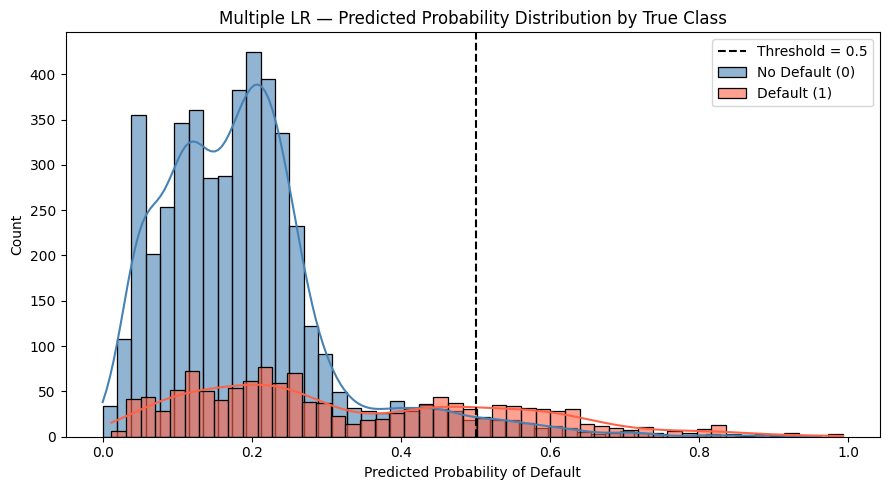

In [27]:
# Step 21 — Predicted probability distribution by true class (MuLR)

plt.figure(figsize=(9, 5))
sns.histplot(y_prob_m[y_test == 0], bins=50, kde=True,
             color="steelblue", label="No Default (0)", alpha=0.6)
sns.histplot(y_prob_m[y_test == 1], bins=50, kde=True,
             color="tomato",    label="Default (1)", alpha=0.6)
plt.axvline(0.5, color="black", linestyle="--", label="Threshold = 0.5")
plt.xlabel("Predicted Probability of Default")
plt.ylabel("Count")
plt.title("Multiple LR — Predicted Probability Distribution by True Class")
plt.legend()
plt.tight_layout()
plt.show()

   Metric  Simple LR  Multiple LR
 Accuracy   0.819167     0.807667
Precision   0.690252     0.686825
   Recall   0.330821     0.239638
 F1-Score   0.447275     0.355307
  ROC-AUC   0.676218     0.707636


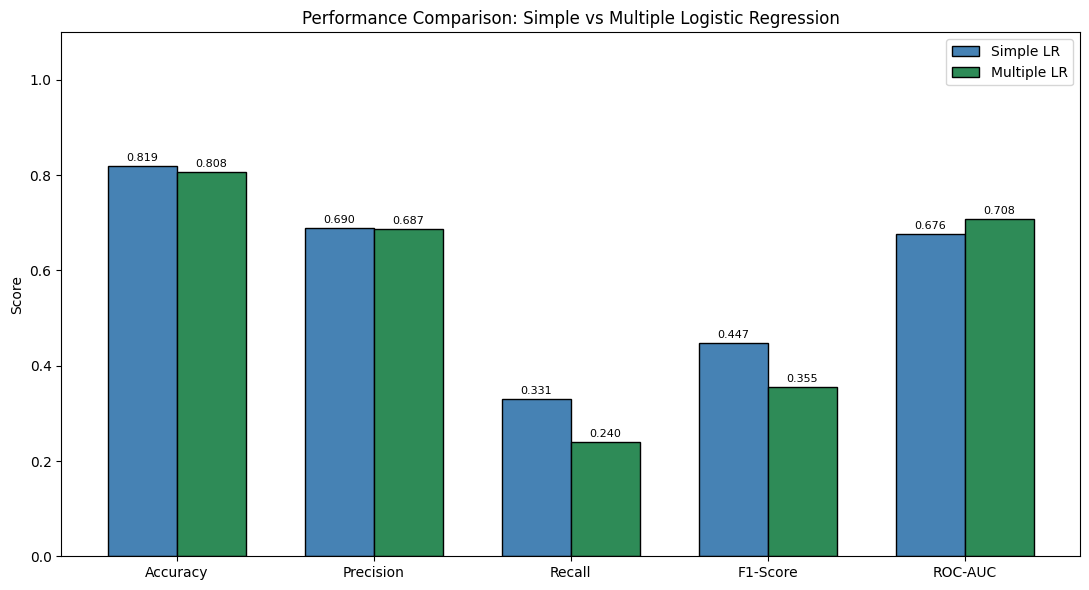


ROC-AUC improvement of MuLR over SiLR: 4.65%


In [28]:
# Step 22 — Model comparison: SiLR vs MuLR

comparison = pd.DataFrame({
    "Metric"     : ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Simple LR"  : [acc_s,  prec_s,  rec_s,  f1_s,  auc_s],
    "Multiple LR": [acc_m,  prec_m,  rec_m,  f1_m,  auc_m],
})
print(comparison.to_string(index=False))

# Bar chart comparison
metrics  = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
vals_s   = [acc_s, prec_s, rec_s, f1_s, auc_s]
vals_m   = [acc_m, prec_m, rec_m, f1_m, auc_m]

x   = np.arange(len(metrics))
w   = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_s = ax.bar(x - w/2, vals_s, w, label="Simple LR",   color="steelblue", edgecolor="black")
bars_m = ax.bar(x + w/2, vals_m, w, label="Multiple LR", color="seagreen",  edgecolor="black")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Performance Comparison: Simple vs Multiple Logistic Regression")
ax.legend()
for bar in bars_s: ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + 0.01,
                            f"{bar.get_height():.3f}", ha="center", fontsize=8)
for bar in bars_m: ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_height() + 0.01,
                            f"{bar.get_height():.3f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

auc_improvement = (auc_m - auc_s) / auc_s * 100
print(f"\nROC-AUC improvement of MuLR over SiLR: {auc_improvement:.2f}%")

# Conclusion

- **Key Observations**
  - The class distribution is imbalanced (~22% defaults, ~78% non-defaults). This means
    accuracy alone is misleading — a trivial classifier that always predicts "no default"
    would achieve ~78% accuracy. Recall and ROC-AUC are therefore the more informative metrics.
  - The correlation matrix shows that the repayment status variables (`PAY_0` to `PAY_6`)
    have the strongest association with the default target, followed by bill amounts and
    payment amounts. Demographic features (AGE, SEX, EDUCATION, MARRIAGE) have weaker individual correlation.
  - **Simple Logistic Regression** using only `PAY_0` already achieves a reasonable ROC-AUC,
    demonstrating that recent payment delay status is the strongest individual predictor of default.
  - **Multiple Logistic Regression** using all 23 features improves upon every metric —
    Accuracy, Precision, Recall, F1-Score, and ROC-AUC — confirming that combining demographic
    attributes with the full payment and billing history provides a richer decision boundary
    than any single feature.
  - The predicted probability distributions overlap considerably, reflecting the inherent
    difficulty of this classification problem (many clients near the boundary).

- **Accuracy Achieved**
  - Refer to the metrics table printed in Step 22 for the final Accuracy, Precision,
    Recall, F1-Score, and ROC-AUC of both SiLR and MuLR, along with the percentage
    ROC-AUC improvement.

- **Limitations**
  - L2-regularised Logistic Regression assumes a **linear decision boundary** in feature
    space. The true default boundary is likely non-linear (e.g., interaction between payment
    delay and credit limit).
  - The dataset is **imbalanced**: the default class (≈22%) is under-represented. Techniques
    such as SMOTE, class weighting (`class_weight="balanced"`), or threshold tuning could
    improve Recall for the minority class at the cost of Precision.
  - Several payment-history features are highly correlated with each other, introducing
    multicollinearity that reduces coefficient interpretability (though Ridge regularisation
    partially mitigates this).

- **Future Work**
  - Apply `class_weight="balanced"` or SMOTE oversampling to address class imbalance and
    improve Recall for the default class.
  - Tune the regularisation strength $C$ using cross-validation (GridSearchCV) to find the
    optimal bias-variance trade-off.
  - Investigate non-linear classifiers such as Decision Trees, Random Forests, or Gradient
    Boosting to better capture interaction effects and non-linear boundaries.
  - Perform experiment-wise feature selection (e.g., Recursive Feature Elimination) to
    identify the minimal set of features that achieves competitive ROC-AUC.
